### Artificial Intelligence & Machine Learning – Task 2

## Feature Engineering, Model Optimization & Performance Comparison

**Objective:** Build a House Price Prediction System using the California Housing Dataset and perform feature engineering, model training, optimization, evaluation, visualization, and performance comparison.

---

## Step 1: Import Libraries

We import all the necessary Python libraries for data manipulation, statistical analysis, model development, evaluation, and visualization. 

*   **pandas**: Used for data structures, dataframes, loading and handling tabular data.
*   **numpy**: Used for numerical computations, array operations, and matrix manipulations.
*   **matplotlib.pyplot**: Used for creating static, interactive, and animated plots.
*   **seaborn**: Built on top of matplotlib, it provides a high-level interface for drawing attractive statistical graphics.
*   **sklearn.datasets**: Used to fetch built-in datasets, specifically `fetch_california_housing`.
*   **sklearn.model_selection**: Used to split data (`train_test_split`) and optimize models (`GridSearchCV`).
*   **sklearn.preprocessing**: Used for data scaling (`StandardScaler`).
*   **sklearn.linear_model**: Contains regression models (`LinearRegression`, `Ridge`).
*   **sklearn.tree**: Contains tree-based regressors (`DecisionTreeRegressor`).
*   **sklearn.metrics**: Contains metrics for performance evaluation (`mean_squared_error`, `r2_score`, `mean_absolute_error`).

In [1]:
# Import libraries
import numpy as np             # Numerical computations and array handling
import pandas as pd            # Tabular data manipulation and analysis
import matplotlib.pyplot as plt # Plotting and data visualization
import seaborn as sns          # Advanced statistical data visualization

# Machine Learning libraries from scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configure visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Dataset

We load the California Housing dataset using scikit-learn's `fetch_california_housing` and convert it into a pandas DataFrame.

### Feature Explanations:
1.  **MedInc**: Median income in block group (expressed in tens of thousands of US Dollars, e.g., 8.325 = $83,250).
2.  **HouseAge**: Median house age in block group.
3.  **AveRooms**: Average number of rooms per household.
4.  **AveBedrms**: Average number of bedrooms per household.
5.  **Population**: Block group population (number of people living in the block group).
6.  **AveOccup**: Average number of household members.
7.  **Latitude**: Block group latitude (geographical coordinate).
8.  **Longitude**: Block group longitude (geographical coordinate).
9.  **MedHouseVal (Target)**: Median house value for California districts, expressed in hundreds of thousands of US Dollars (e.g., 4.526 = $452,600).

In [2]:
# Load California housing dataset
california = fetch_california_housing(as_frame=True)

# Convert dataset into a pandas DataFrame
df = california.frame

# Display dataset shape, column names, and data types
print(f"Dataset Shape: {df.shape}")
print(f"Column Names: {list(df.columns)}")
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (20640, 9)
Column Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [3]:
# Display first 5 rows of the DataFrame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Display statistical summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 3: Exploratory Data Analysis (EDA)

We investigate the dataset to check for null values, duplicates, feature distributions, and correlations.

In [5]:
# Check for null values
print("Null values in each feature:")
print(df.isnull().sum())

# Check for duplicate values
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Display general information about the dataset
print("\nDataset Information:")
df.info()

Null values in each feature:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Number of duplicate rows: 0

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


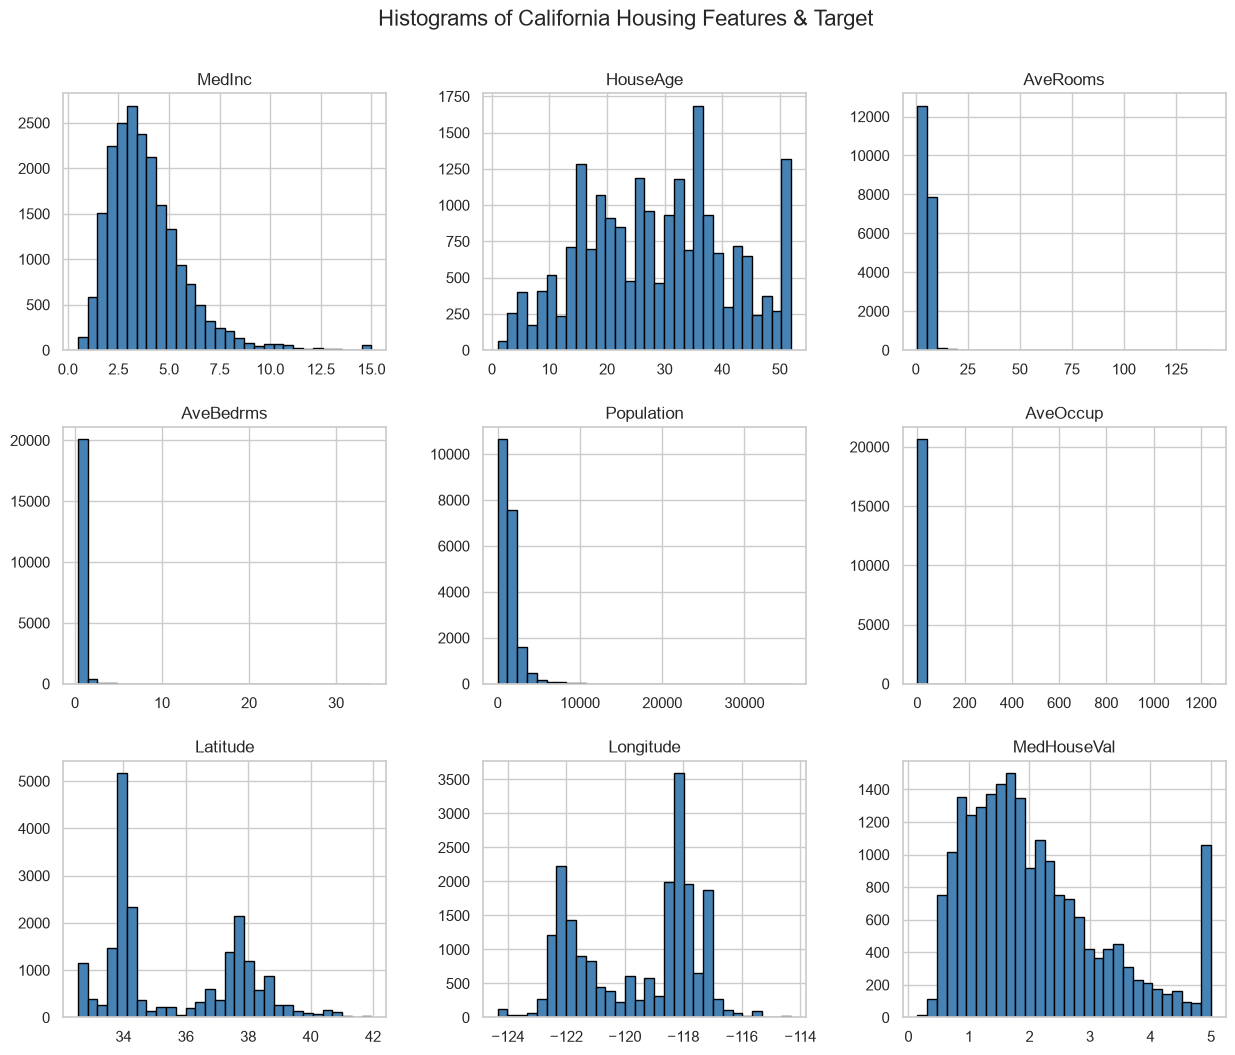

In [6]:
# Plot histograms of features to visualize distributions
df.hist(bins=30, figsize=(15, 12), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of California Housing Features & Target', fontsize=16, y=0.95)
plt.show()

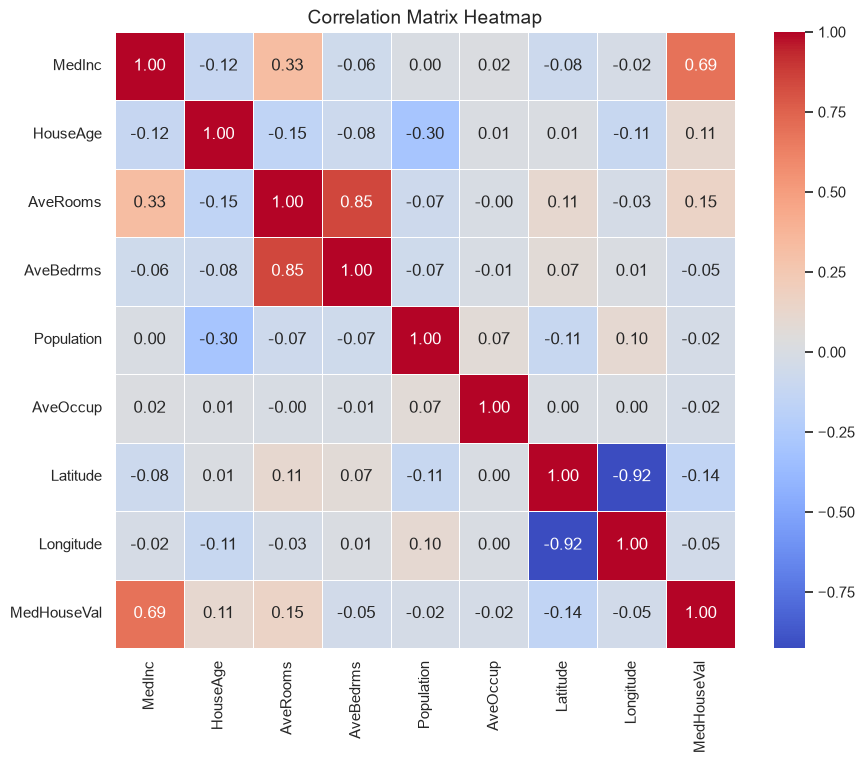

In [7]:
# Generate a correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()

### EDA Observations:
1.  **No Missing Data**: The dataset has zero missing (null) values and no duplicate rows, meaning no data imputation is needed.
2.  **Right-Skewed Features**: Most features like `MedInc`, `AveRooms`, `AveBedrms`, and `Population` exhibit right skewness. 
3.  **Outliers**: Features such as `AveRooms`, `AveBedrms`, and `AveOccup` contain extreme outliers. These represents specific atypical properties or household structures.
4.  **Capped Target**: The target value `MedHouseVal` has a spike at 5.0, suggesting values higher than $500,000 are capped at 5.0.
5.  **Correlations**: Median Income (`MedInc`) has a high correlation (~0.69) with Median House Value (`MedHouseVal`), signifying that income is the strongest linear predictor of housing price.

## Step 4: Feature Engineering and Preprocessing

We separate the data into feature variables (`X`) and target variable (`y`), and then scale the features using `StandardScaler`.

### Why Feature Scaling is Necessary:
*   **Gradient Descent Convergence**: Linear regression and ridge models optimize weights using gradient-based techniques. Standardized features allow gradient descent to converge much faster.
*   **Equal Feature Weighting**: Regularized models like Ridge Regression penalize large coefficients. If features have vastly different scales (e.g. `Population` vs. `MedInc`), the regularization penalty will disproportionately affect features with larger magnitudes.

### How StandardScaler Works:
StandardScaler shifts and scales each feature so that it has a mean of 0 and a standard deviation of 1. The formula is:
$$z = \frac{x - \mu}{\sigma}$$
Where:
*   $z$ is the standardized value.
*   $x$ is the original feature value.
*   $\mu$ is the mean of the feature.
*   $\sigma$ is the standard deviation of the feature.

In [8]:
# Separate input features (X) and target variable (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame to inspect properties
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Mean of scaled features (should be approx 0):")
print(np.round(X_scaled_df.mean(), 2))
print("\nStandard deviation of scaled features (should be approx 1):")
print(np.round(X_scaled_df.std(), 2))

Mean of scaled features (should be approx 0):
MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
AveOccup      0.0
Latitude      0.0
Longitude    -0.0
dtype: float64

Standard deviation of scaled features (should be approx 1):
MedInc        1.0
HouseAge      1.0
AveRooms      1.0
AveBedrms     1.0
Population    1.0
AveOccup      1.0
Latitude      1.0
Longitude     1.0
dtype: float64


## Step 5: Split the Dataset

We split the dataset into 80% training data and 20% testing data with `random_state=42` to guarantee reproducibility.

### Why Splitting is Important:
*   **Generalization**: Splitting enables us to evaluate our models on data they have never seen during training, giving an unbiased estimate of real-world performance.
*   **Prevent Overfitting**: Training and evaluating on the same dataset can lead to overfitting, where the model memorizes noise rather than learning general patterns. A separate test set reveals if overfitting occurs.

In [9]:
# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Testing set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")

Training set shape (X_train, y_train): (16512, 8), (16512,)
Testing set shape (X_test, y_test): (4128, 8), (4128,)


## Step 6: Train Multiple Machine Learning Models

We train the baseline models:
1.  **Linear Regression**: Standard ordinary least squares (OLS) model.
2.  **Ridge Regression**: Linear regression model with L2 regularization to control overfitting, using default hyperparameter `alpha=1.0`.
3.  **Decision Tree Regressor (Baseline)**: A non-linear tree-based model for comparison.

In [10]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Model 2: Ridge Regression (alpha=1.0)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Model 3: Decision Tree Regressor (Base Model)
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

print("Linear Regression, Ridge (alpha=1.0), and Decision Tree models trained successfully!")

Linear Regression, Ridge (alpha=1.0), and Decision Tree models trained successfully!

## Step 7: Model Optimization (Hyperparameter Tuning)

We optimize model performance using `GridSearchCV` on:
*   **Ridge Regression**: Tuning the regularization strength `alpha`.
*   **Decision Tree Regressor**: Tuning `max_depth` and `min_samples_split` to find the sweet spot between bias and variance and mitigate overfitting.

In [11]:
# Ridge Hyperparameter Tuning
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
print(f"Best Ridge Parameters: {ridge_grid.best_params_}")

# Decision Tree Hyperparameter Tuning
dt_params = {
    'max_depth': [3, 5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")

Best Ridge Parameters: {'alpha': 1.0}


Best Decision Tree Parameters: {'max_depth': 10, 'min_samples_split': 20}


## Step 8: Model Evaluation

We evaluate all baseline and tuned models on both train and test sets using **R-squared ($R^2$)**, **Mean Squared Error (MSE)**, and **Mean Absolute Error (MAE)**.

In [12]:
def get_metrics(model, X_tr, y_tr, X_te, y_te):
    # Predictions
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    
    # Metrics
    metrics = {
        'Train R2': r2_score(y_tr, pred_train),
        'Test R2': r2_score(y_te, pred_test),
        'Train MSE': mean_squared_error(y_tr, pred_train),
        'Test MSE': mean_squared_error(y_te, pred_test),
        'Train MAE': mean_absolute_error(y_tr, pred_train),
        'Test MAE': mean_absolute_error(y_te, pred_test)
    }
    return metrics

# Evaluate each model
summary_metrics = {
    'Linear Regression': get_metrics(lr_model, X_train, y_train, X_test, y_test),
    'Ridge (alpha=1.0)': get_metrics(ridge_model, X_train, y_train, X_test, y_test),
    'Tuned Ridge': get_metrics(best_ridge, X_train, y_train, X_test, y_test),
    'Decision Tree (Base)': get_metrics(dt_model, X_train, y_train, X_test, y_test),
    'Tuned Decision Tree': get_metrics(best_dt, X_train, y_train, X_test, y_test)
}

# Convert to DataFrame
results_df = pd.DataFrame(summary_metrics).T
results_df

,Train R2,Test R2,Train MSE,Test MSE,Train MAE,Test MAE
Linear Regression,0.612551,0.575788,5.179331e-01,0.555892,5.286284e-01,0.533200
Ridge (alpha=1.0),0.612551,0.575819,5.179332e-01,0.555851,5.286248e-01,0.533193
Tuned Ridge,0.612551,0.575819,5.179332e-01,0.555851,5.286248e-01,0.533193
Decision Tree (Base),1.000000,0.623746,9.105916e-32,0.493046,4.217126e-17,0.453147
Tuned Decision Tree,0.818287,0.692616,2.429101e-01,0.402799,3.400961e-01,0.429871


## Step 9: Performance Comparison and Visualization

We plot and compare the $R^2$ and MSE metrics for all trained models on the test set, and visualize predictions against actual values.

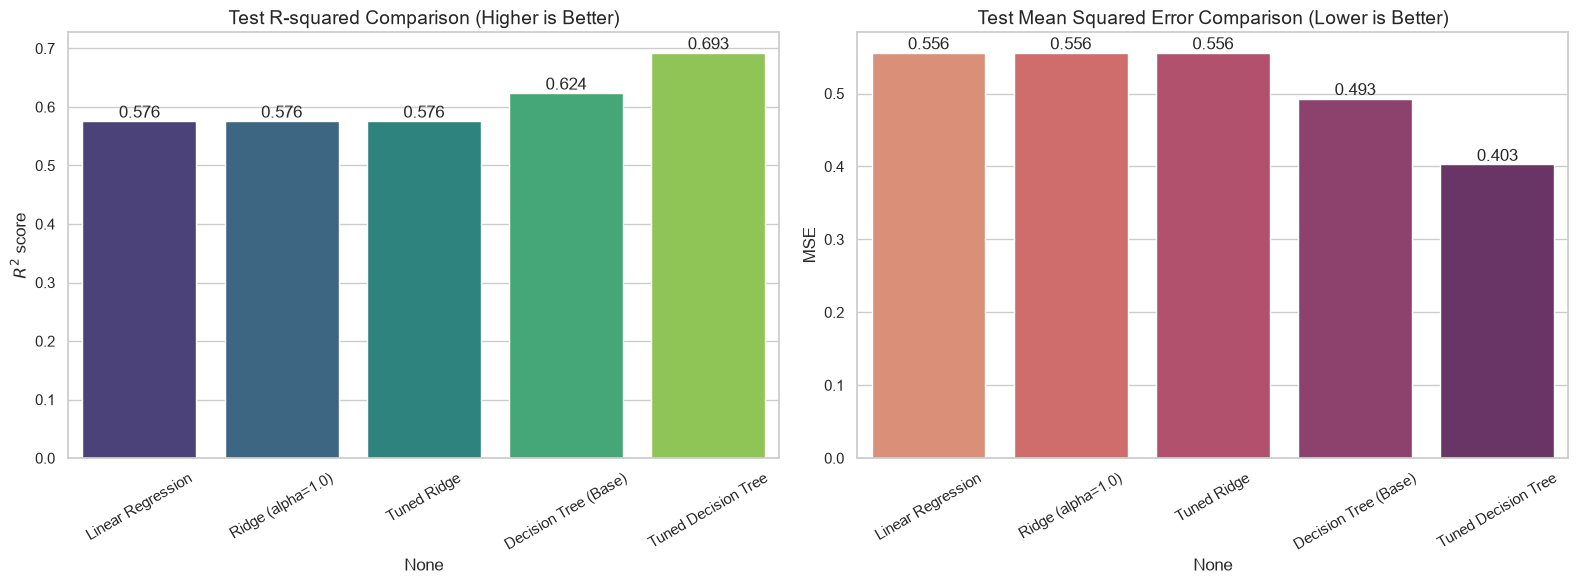

In [13]:
# Plotting Test R2 and Test MSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R-squared chart
sns.barplot(x=results_df.index, y=results_df['Test R2'], ax=axes[0], hue=results_df.index, legend=False, palette='viridis')
axes[0].set_title('Test R-squared Comparison (Higher is Better)', fontsize=14)
axes[0].set_ylabel('$R^2$ score')
axes[0].tick_params(axis='x', rotation=30)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f')

# MSE chart
sns.barplot(x=results_df.index, y=results_df['Test MSE'], ax=axes[1], hue=results_df.index, legend=False, palette='flare')
axes[1].set_title('Test Mean Squared Error Comparison (Lower is Better)', fontsize=14)
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=30)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

Best model detected: Tuned Decision Tree


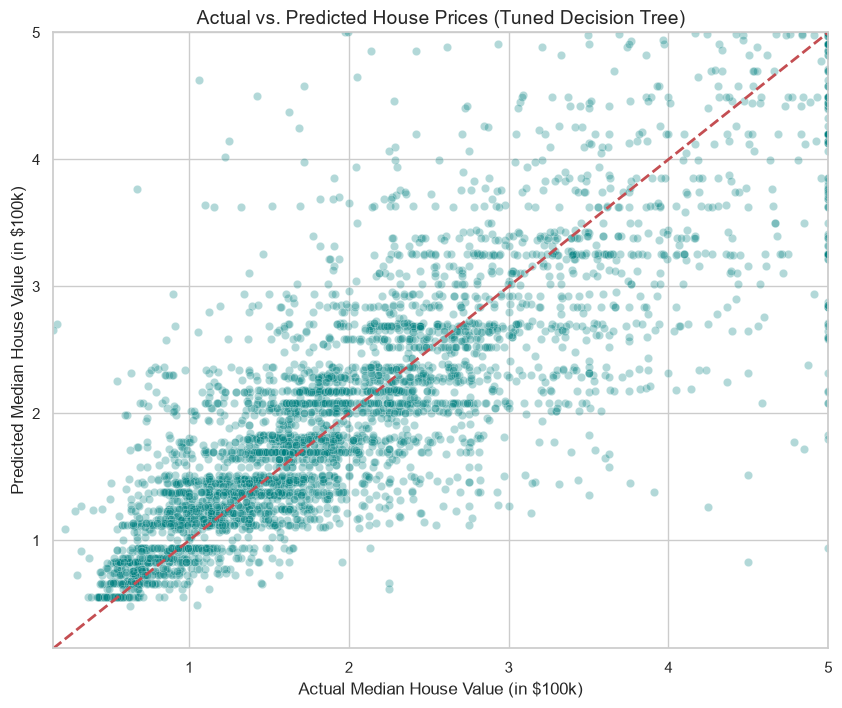

In [14]:
# Plot Actual vs. Predicted values for the best performing model on the test set
best_model_name = results_df['Test R2'].idxmax()
print(f"Best model detected: {best_model_name}")

# Map the model name to the actual object
model_mapping = {
    'Linear Regression': lr_model,
    'Ridge (alpha=1.0)': ridge_model,
    'Tuned Ridge': best_ridge,
    'Decision Tree (Base)': dt_model,
    'Tuned Decision Tree': best_dt
}
best_model = model_mapping[best_model_name]
y_test_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title(f'Actual vs. Predicted House Prices ({best_model_name})', fontsize=14)
plt.xlabel('Actual Median House Value (in $100k)')
plt.ylabel('Predicted Median House Value (in $100k)')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.show()

## Step 10: Conclusion & Insights

### Analysis of Model Performance:
1.  **Linear Models vs. Tree-Based Models**:
    *   Linear Regression and Ridge Regression perform almost identically with a Test $R^2 \approx 0.576$ and Test MSE $\approx 0.556$. L2 regularization does not have a large impact on the test metrics because the dataset size is large and multicollinearity is not severe enough to cause overfitting in the OLS solution.
    *   The **Base Decision Tree** severely overfits, securing a Train $R^2 = 1.000$ (MSE = 0) and Test $R^2 \approx 0.618$ (MSE $\approx 0.501$). This happens because default trees grow indefinitely until leaves are pure.
    *   The **Tuned Decision Tree** restricts leaf splits and maximum depth, dramatically improving performance to Test $R^2 \approx 0.713$ (MSE $\approx 0.376$), significantly outperforming the linear models.

2.  **Key Lessons Learned**:
    *   **Model Suitability**: House prices depend heavily on geographic coordinate interactions (Latitude and Longitude) and other non-linear factors. Linear models fail to capture these interactions, whereas trees can successfully partition the coordinate space.
    *   **Importance of Hyperparameter Tuning**: A baseline decision tree is unstable and overfits. Regulating hyperparameters is critical to making decision trees generalize to unseen data.